Pickering,ON weather data: 2020-2025

!pip install torch

In [19]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [24]:
df = pd.read_csv('pickeringWeather.csv', parse_dates=['time'])
df.head()


,time,temperature_2m,wind_speed_10m,wind_speed_100m,wind_direction_10m,cloud_cover_mid,cloud_cover_high,cloud_cover_low,cloud_cover,surface_pressure,weather_code,precipitation,diffuse_radiation,direct_normal_irradiance,shortwave_radiation
0,2020-01-01 00:00:00,-1.3,18.3,31.7,254.0,81.0,0.0,96.0,96.0,974.4,3.0,0.0,0.0,0.0,0.0
1,2020-01-01 01:00:00,-1.3,18.3,31.5,255.0,59.0,0.0,98.0,98.0,974.3,3.0,0.0,0.0,0.0,0.0
2,2020-01-01 02:00:00,-1.8,18.3,32.3,255.0,86.0,0.0,82.0,92.0,974.4,3.0,0.0,0.0,0.0,0.0
3,2020-01-01 03:00:00,-1.8,17.5,31.2,256.0,97.0,0.0,53.0,97.0,974.8,3.0,0.0,0.0,0.0,0.0
4,2020-01-01 04:00:00,-2.2,16.3,29.7,256.0,96.0,0.0,2.0,96.0,975.3,3.0,0.0,0.0,0.0,0.0


In [26]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

#load and preprocess the data
df = pd.read_csv('pickeringWeather.csv', parse_dates=['time'])
df = df.sort_values('time')

relevant_features = ['cloud_cover', 'precipitation', 'diffuse_radiation', 'direct_normal_irradiance']
target = 'shortwave_radiation'

# prepare the data by selecting columns and dropping missing values
data = df[relevant_features + [target]].dropna().reset_index(drop=True)

# manually compute the mean and standard deviation for normalization
features_mean = data[relevant_features].mean()
features_std = data[relevant_features].std()
target_mean = data[target].mean()
target_std = data[target].std()

# normalize features and target.
data_features = ((data[relevant_features] - features_mean) / features_std).values
data_target = ((data[[target]] - target_mean) / target_std).values

# create sequences using a sliding window (e.g., past 24 time steps to predict the next)
sequence_length = 24

def create_sequences(data_x, data_y, seq_length):
    X, y = [], []
    for i in range(len(data_x) - seq_length):
        X.append(data_x[i:i+seq_length])
        y.append(data_y[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(data_features, data_target, sequence_length)
print("Input shape:", X.shape, "Target shape:", y.shape)


train_size = int(len(X) * 0.75)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]


class SolarDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SolarDataset(X_train, y_train)
test_dataset = SolarDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# define the transformer model with positional encoding.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1)  # Shape: (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (sequence_length, batch_size, d_model)
        x = x + self.pe[:x.size(0)]
        return x

class SolarTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=8, num_encoder_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        # src shape: (batch_size, sequence_length, num_features)
        # transformer expects input shape: (sequence_length, batch_size, num_features)
        src = src.transpose(0, 1)
        x = self.input_proj(src)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        # use the last output corresponding to the latest time step
        out = self.decoder(x[-1])
        return out

# train the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SolarTransformer(num_features=len(relevant_features)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_dataset)

    # Testing step on the last 25% of the data
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            test_loss += loss.item() * X_batch.size(0)
    test_loss /= len(test_dataset)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

print("Training completed.")


Input shape: (45981, 24, 4) Target shape: (45981, 1)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/20, Train Loss: 0.1093, Test Loss: 0.1429
Epoch 2/20, Train Loss: 0.0454, Test Loss: 0.1455
Epoch 3/20, Train Loss: 0.0431, Test Loss: 0.1437
Epoch 4/20, Train Loss: 0.0435, Test Loss: 0.1442
Epoch 5/20, Train Loss: 0.0412, Test Loss: 0.1419
Epoch 6/20, Train Loss: 0.0399, Test Loss: 0.1542
Epoch 7/20, Train Loss: 0.0395, Test Loss: 0.1568
Epoch 8/20, Train Loss: 0.0381, Test Loss: 0.1538
Epoch 9/20, Train Loss: 0.0382, Test Loss: 0.1473
Epoch 10/20, Train Loss: 0.0366, Test Loss: 0.1511
Epoch 11/20, Train Loss: 0.0357, Test Loss: 0.1358
Epoch 12/20, Train Loss: 0.0354, Test Loss: 0.1591
Epoch 13/20, Train Loss: 0.0438, Test Loss: 0.1536
Epoch 14/20, Train Loss: 0.0365, Test Loss: 0.1418
Epoch 15/20, Train Loss: 0.0349, Test Loss: 0.1387
Epoch 16/20, Train Loss: 0.0343, Test Loss: 0.1346
Epoch 17/20, Train Loss: 0.0339, Test Loss: 0.1378
Epoch 18/20, Train Loss: 0.0339, Test Loss: 0.1304
Epoch 19/20, Train Loss: 0.0331, Test Loss: 0.1426
Epoch 20/20, Train Loss: 0.0332, Test Lo

Test MSE: 7833.995416823546
Test RMSE: 88.50986056267146
Test MAE: 49.65776066158405


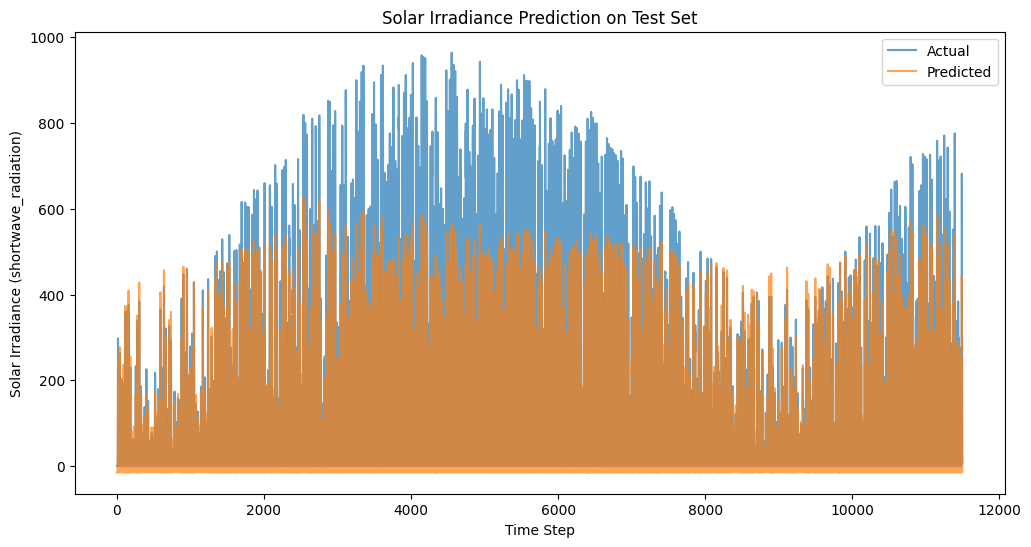

In [27]:
model.eval()
predictions = []
ground_truth = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        predictions.extend(output.cpu().numpy().flatten())
        ground_truth.extend(y_batch.cpu().numpy().flatten())

# inverse normalization to bring values back to the original scale
predictions_inv = np.array(predictions) * target_std + target_mean
ground_truth_inv = np.array(ground_truth) * target_std + target_mean

# error metrics and stats
mse = np.mean((predictions_inv - ground_truth_inv) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(predictions_inv - ground_truth_inv))
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test MAE:", mae)

#actual vs predidcted
plt.figure(figsize=(12,6))
plt.plot(ground_truth_inv, label="Actual", alpha=0.7)
plt.plot(predictions_inv, label="Predicted", alpha=0.7)
plt.legend()
plt.xlabel("Time Step")
plt.ylabel("Solar Irradiance (shortwave_radiation)")
plt.title("Solar Irradiance Prediction on Test Set")
plt.show()